# 03 — Face Preprocessing

Extracts **K representative face crops per utterance** from the MELD video clips.

## Pipeline
1. Sample frames every `FACE_FRAME_STRIDE` frames.
2. Detect all faces per frame with **MTCNN**.
3. Select the speaker's face:
   - Always keep the **largest** face as the default.
   - When multiple faces are present, use **InceptionResnetV1** (VGGFace2) embeddings
     to match the face most similar to the speaker's running reference.
4. Score each frame with **EmotiEffLib `enet_b0_8_best_afew`** (trained on TV/movie clips):
   `score = gt_prob_renorm × max_prob_renorm`
5. Smooth the score curve with a Gaussian window.
6. Pick K frames via `scipy.signal.find_peaks` (greedy top-K fallback).
7. Save selected face crops as **PNG** files.

## Outputs
```
../Data/processed_meld_faces/<version>/<split>/
    images/          ← PNG face crops
    analysis/        ← per-utterance .npz with full per-frame data
    metadata.csv     ← one row per saved frame
```

Run is **resumable**: already-processed utterances are skipped based on `metadata.csv`.
The buffer is flushed to disk on every crash or `KeyboardInterrupt`.

In [1]:
import os
import sys

_here = os.path.abspath(os.getcwd())
_root = _here if os.path.isdir(os.path.join(_here, 'src')) else os.path.abspath(os.path.join(_here, '..'))
if _root not in sys.path:
    sys.path.insert(0, _root)

In [3]:
import numpy as np
import pandas as pd
import torch
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from facenet_pytorch import MTCNN, InceptionResnetV1
from emotiefflib.facial_analysis import EmotiEffLibRecognizer

from src.config import (
    DEVICE,
    FACE_FER_MODEL, FACE_MELD_CLASSES,
    FACE_K_FRAMES, FACE_FRAME_STRIDE, FACE_MIN_GAP_S,
    FACE_EXPAND_SCALE, FACE_MIN_FACE_PX, FACE_SMOOTH_SIGMA_S,
    FACE_VIDEO_DIRS, FACE_CSV_PATHS, FACE_OUTPUT_ROOT,
    VERSION,
)
from src.data.face_preprocessing import (
    SpeakerEmbeddingTracker,
    normalise_emotion,
    remap_8_to_7,
    pick_largest_box,
    expand_and_clip_box,
    get_face_embedding,
    smooth_scores,
    select_frames,
    process_utterance,
    run_all_splits,
)

print('Device:', DEVICE)
print('FER model:', FACE_FER_MODEL)

Device: cuda
FER model: enet_b0_8_best_afew


## Config overview

All parameters live in `src/config.py`. Quick summary:

In [4]:
print(f'  K frames per utterance : {FACE_K_FRAMES}')
print(f'  Frame stride           : {FACE_FRAME_STRIDE}  (sample every {FACE_FRAME_STRIDE} frames)')
print(f'  Min gap between frames : {FACE_MIN_GAP_S}s')
print(f'  Box expansion scale    : {FACE_EXPAND_SCALE}')
print(f'  Minimum face size      : {FACE_MIN_FACE_PX}px')
print(f'  Score smoothing sigma  : {FACE_SMOOTH_SIGMA_S}s')
print(f'  Output version         : {VERSION}')
print(f'  Output root            : {FACE_OUTPUT_ROOT}')

  K frames per utterance : 5
  Frame stride           : 3  (sample every 3 frames)
  Min gap between frames : 0.3s
  Box expansion scale    : 1.2
  Minimum face size      : 48px
  Score smoothing sigma  : 0.5s
  Output version         : v1
  Output root            : ../Data/processed_meld_faces


## Load models (shared for demo and full run)

In [5]:
mtcnn  = MTCNN(keep_all=True, device=DEVICE)
resnet = InceptionResnetV1(pretrained='vggface2').eval().to(DEVICE)
fer    = EmotiEffLibRecognizer(engine='torch', model_name=FACE_FER_MODEL, device=DEVICE)

print('Models loaded.')

100%|██████████| 107M/107M [00:01<00:00, 71.9MB/s] 


Models loaded.


---
## Demo — single utterance walkthrough

Visualises the full pipeline on one clip so you can verify face detection, scoring,
smoothing, and frame selection before running everything.

In [6]:
# ── Pick a demo utterance ─────────────────────────────────────────────────────
DEMO_SPLIT    = 'train'
DEMO_D_ID     = 0
DEMO_U_ID     = 0

demo_video = os.path.join(
    FACE_VIDEO_DIRS[DEMO_SPLIT],
    f'dia{DEMO_D_ID}_utt{DEMO_U_ID}.mp4'
)
print('Video:', demo_video)
print('Exists:', os.path.exists(demo_video))

demo_df = pd.read_csv(FACE_CSV_PATHS[DEMO_SPLIT])
demo_row = demo_df[
    (demo_df['Dialogue_ID'] == DEMO_D_ID) & (demo_df['Utterance_ID'] == DEMO_U_ID)
].iloc[0]
demo_emo  = normalise_emotion(demo_row['Emotion'])
demo_spkr = demo_row.get('Speaker', None)
print(f'Emotion: {demo_emo}  |  Speaker: {demo_spkr}')

Video: ../Data/MELD.Raw/train/train_splits\dia0_utt0.mp4
Exists: True
Emotion: Neutral  |  Speaker: Chandler


In [7]:
# ── Collect per-frame scores (abbreviated version of process_utterance) ───────
from src.data.face_preprocessing import _MELD_CLASS_TO_IDX7

cap  = cv2.VideoCapture(demo_video)
fps  = cap.get(cv2.CAP_PROP_FPS) or 25.0
emo_idx = _MELD_CLASS_TO_IDX7[demo_emo]

demo_frame_idxs, demo_times, demo_scores_raw, demo_scores_comb = [], [], [], []
demo_probs7 = []

fi = 0
while True:
    ok, frame_bgr = cap.read()
    if not ok:
        break
    if fi % FACE_FRAME_STRIDE != 0:
        fi += 1
        continue

    img_h, img_w = frame_bgr.shape[:2]
    pil_img = Image.fromarray(cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB))
    boxes, _ = mtcnn.detect(pil_img)
    box = pick_largest_box(boxes)
    if box is None:
        fi += 1
        continue

    x1, y1, x2, y2 = expand_and_clip_box(box, img_w, img_h)
    if (x2 - x1) < FACE_MIN_FACE_PX or (y2 - y1) < FACE_MIN_FACE_PX:
        fi += 1
        continue

    face_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)[y1:y2, x1:x2]
    _, probs_raw = fer.predict_emotions(face_rgb, logits=False)
    probs_7 = remap_8_to_7(probs_raw[0])
    gt_p, max_p = float(probs_7[emo_idx]), float(probs_7.max())

    demo_frame_idxs.append(fi)
    demo_times.append(fi / fps)
    demo_scores_raw.append(gt_p)
    demo_scores_comb.append(gt_p * max_p)
    demo_probs7.append(probs_7)
    fi += 1

cap.release()
print(f'Frames with face detected: {len(demo_frame_idxs)}')

Frames with face detected: 46


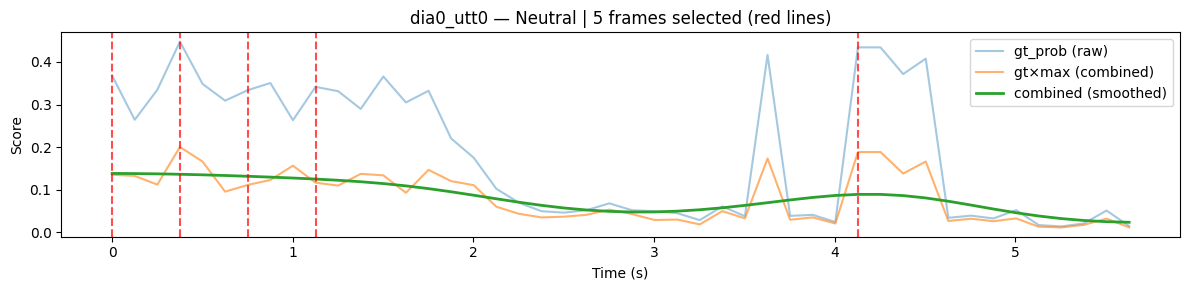

In [8]:
# ── Plot score curves and selected frames ─────────────────────────────────────
if demo_frame_idxs:
    s_comb  = np.array(demo_scores_comb, dtype=np.float32)
    s_smooth = smooth_scores(s_comb, demo_frame_idxs, fps)
    min_gap_frames = max(1, int(round(fps * FACE_MIN_GAP_S)))
    picked = select_frames(demo_frame_idxs, s_smooth, FACE_K_FRAMES, min_gap_frames)

    fig, ax = plt.subplots(figsize=(12, 3))
    ax.plot(demo_times, demo_scores_raw,  alpha=0.4, label='gt_prob (raw)')
    ax.plot(demo_times, s_comb,           alpha=0.6, label='gt×max (combined)')
    ax.plot(demo_times, s_smooth,                    label='combined (smoothed)', linewidth=2)
    for p in picked:
        ax.axvline(demo_times[p], color='red', linestyle='--', alpha=0.7)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Score')
    ax.set_title(f'dia{DEMO_D_ID}_utt{DEMO_U_ID} — {demo_emo} | {len(picked)} frames selected (red lines)')
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print('No faces detected in demo clip.')

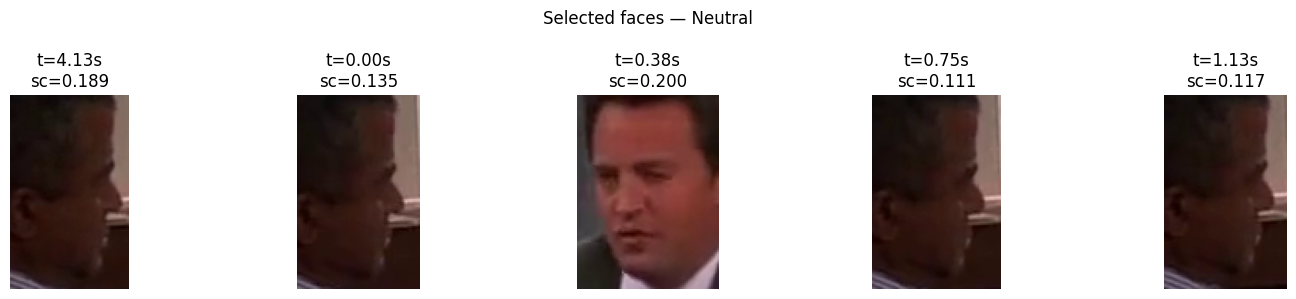

In [9]:
# ── Show the selected face crops ──────────────────────────────────────────────
if demo_frame_idxs and picked:
    cap = cv2.VideoCapture(demo_video)
    fig, axes = plt.subplots(1, len(picked), figsize=(3 * len(picked), 3))
    if len(picked) == 1:
        axes = [axes]

    for ax, idx in zip(axes, picked):
        cap.set(cv2.CAP_PROP_POS_FRAMES, demo_frame_idxs[idx])
        ok, frame_bgr = cap.read()
        if not ok:
            ax.axis('off')
            continue
        img_h, img_w = frame_bgr.shape[:2]
        # Re-detect to get box (demo only — in the main pipeline we cache it)
        pil_img = Image.fromarray(cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB))
        boxes, _ = mtcnn.detect(pil_img)
        box = pick_largest_box(boxes)
        if box is not None:
            x1, y1, x2, y2 = expand_and_clip_box(box, img_w, img_h)
            face = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)[y1:y2, x1:x2]
            ax.imshow(face)
        ax.set_title(f't={demo_times[idx]:.2f}s\nsc={demo_scores_comb[idx]:.3f}')
        ax.axis('off')

    cap.release()
    plt.suptitle(f'Selected faces — {demo_emo}', fontsize=12)
    plt.tight_layout()
    plt.show()

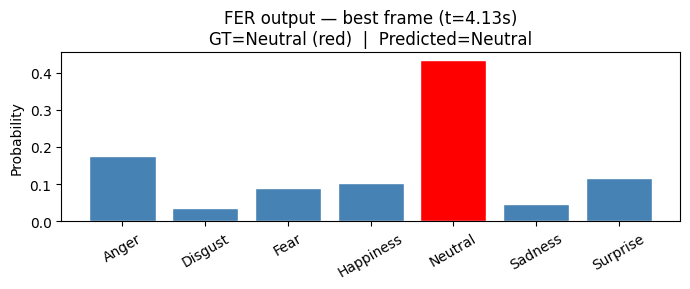

In [10]:
# ── Show per-class probability breakdown for the best-scoring frame ───────────
if demo_frame_idxs and picked:
    best_idx  = picked[0]
    best_p7   = demo_probs7[best_idx]

    fig, ax = plt.subplots(figsize=(7, 3))
    colours = ['red' if c == demo_emo else 'steelblue' for c in FACE_MELD_CLASSES]
    ax.bar(FACE_MELD_CLASSES, best_p7, color=colours, edgecolor='white')
    ax.set_ylabel('Probability')
    ax.set_title(
        f'FER output — best frame (t={demo_times[best_idx]:.2f}s)\n'
        f'GT={demo_emo} (red)  |  Predicted={FACE_MELD_CLASSES[int(np.argmax(best_p7))]}'
    )
    ax.tick_params(axis='x', rotation=30)
    plt.tight_layout()
    plt.show()

---
## Full preprocessing run — all splits

Processes **train → dev → test** in sequence.  
The buffer is always flushed to `metadata.csv` on exit (normal or crash).  
To resume a partial run, just re-run this cell — already-processed utterances are skipped.

**Optional overrides** — change these without touching `config.py`:

In [11]:
# ── Optional parameter overrides ──────────────────────────────────────────────
# Leave as-is to use src/config.py defaults.
k_frames      = FACE_K_FRAMES        # frames to save per utterance
frame_stride  = FACE_FRAME_STRIDE    # sample every Nth frame
min_gap_s     = FACE_MIN_GAP_S       # minimum seconds between selected frames
expand_scale  = FACE_EXPAND_SCALE    # face box expansion factor
min_face_px   = FACE_MIN_FACE_PX     # minimum face dimension (px)
smooth_sigma_s = FACE_SMOOTH_SIGMA_S # Gaussian smoothing window (seconds)
max_utterances = None                # set e.g. 50 for a quick test run

print('Running with:')
print(f'  k_frames={k_frames}, stride={frame_stride}, min_gap={min_gap_s}s')
print(f'  expand={expand_scale}, min_px={min_face_px}, sigma={smooth_sigma_s}s')
print(f'  version={VERSION}, output_root={FACE_OUTPUT_ROOT}')

Running with:
  k_frames=5, stride=3, min_gap=0.3s
  expand=1.2, min_px=48, sigma=0.5s
  version=v1, output_root=../Data/processed_meld_faces


In [ ]:
# ── Run ───────────────────────────────────────────────────────────────────────
# Models are already loaded above; run_all_splits will re-load them internally
# if called standalone. Here we call process_utterance directly via run_all_splits.

metadata_paths = run_all_splits(
    splits=['train', 'dev', 'test'],
    version=VERSION,
    k_frames=k_frames,
    frame_stride=frame_stride,
    min_gap_s=min_gap_s,
    expand_scale=expand_scale,
    min_face_px=min_face_px, 
    smooth_sigma_s=smooth_sigma_s,
    max_utterances=max_utterances,
)

print('\nDone. Metadata files:')
for split, path in metadata_paths.items():
    print(f'  [{split}] {path}') 

Loading MTCNN …
Loading InceptionResnetV1 (VGGFace2) …
Loading FER model: enet_b0_8_best_afew …

  Processing split: train


train: 100%|██████████| 9989/9989 [13:19:13<00:00,  4.80s/it]  



  [train] Flushed. Metadata → ../Data/processed_meld_faces\v1\train\metadata.csv

  Processing split: dev


dev: 100%|██████████| 1109/1109 [1:24:10<00:00,  4.55s/it]



  [dev] Flushed. Metadata → ../Data/processed_meld_faces\v1\dev\metadata.csv

  Processing split: test


test: 100%|██████████| 2610/2610 [3:34:25<00:00,  4.93s/it]    


  [test] Flushed. Metadata → ../Data/processed_meld_faces\v1\test\metadata.csv

Done. Metadata files:
  [train] ../Data/processed_meld_faces\v1\train\metadata.csv
  [dev] ../Data/processed_meld_faces\v1\dev\metadata.csv
  [test] ../Data/processed_meld_faces\v1\test\metadata.csv


## Post-run summary

In [ ]:
summary_rows = []
for split, path in metadata_paths.items():
    if not os.path.exists(path):
        continue
    m = pd.read_csv(path)
    ok   = m[m['status'] == 'ok']
    summary_rows.append({
        'split':              split,
        'total_utterances':   m[['dialogue_id','utterance_id']].drop_duplicates().shape[0],
        'saved_frames':       len(ok),
        'missing_video':      (m['status'] == 'missing_video').sum(),
        'no_faces':           (m['status'] == 'no_faces_detected').sum(),
        'errors':             m['status'].str.startswith('error').sum(),
    })

pd.DataFrame(summary_rows)

In [ ]:
# ── Score distribution across saved frames (train) ────────────────────────────
train_meta_path = metadata_paths.get('train')
if train_meta_path and os.path.exists(train_meta_path):
    m = pd.read_csv(train_meta_path)
    ok = m[m['status'] == 'ok'].copy()

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    ok['score_comb'].hist(bins=40, ax=axes[0], color='steelblue', edgecolor='white')
    axes[0].set_xlabel('score = gt_prob × max_prob')
    axes[0].set_ylabel('Saved frames')
    axes[0].set_title('Score distribution (train)')

    emotion_counts = ok.groupby('emotion_norm')['score_comb'].mean().sort_values()
    emotion_counts.plot(kind='barh', ax=axes[1], color='steelblue', edgecolor='white')
    axes[1].set_xlabel('Mean score')
    axes[1].set_title('Mean score per emotion (train)')

    plt.tight_layout()
    plt.show()